# Value and Momentum: From Signals to Factor Forecasts

## Project Objective

The purpose of this project is to empirically explore several forecasting concepts from Grinold and Kahn using a fixed universe of U.S. equities.

The analysis will use monthly observations from 2010 through 2025 and SPY as the market benchmark. Additional historical price data prior to 2010 will be downloaded where necessary to construct signals that require long lookback periods.

Two stock-level signals will be studied:

1. **Momentum**
2. **Price-based Value**

The momentum signal will measure medium-term return continuation using returns from months $t-12$ through $t-2$:

$$
MOM_{i,t}
=
\prod_{k=2}^{12}(1+r_{i,t-k})-1
$$

The most recent month is excluded to avoid mixing medium-term momentum with short-term reversal.

The value signal will use long-term price reversal as a price-only proxy for value. It will be defined as the negative of the stock's cumulative five-year return:

$$
VAL_{i,t}
=
-
\left[
\prod_{k=1}^{60}(1+r_{i,t-k})-1
\right]
$$

A stock that has performed poorly over the previous five years therefore receives a higher value score, while a stock that has performed exceptionally well receives a lower value score.

Each month, both signals will be standardized across the stock universe:

$$
z_{i,t}
=
\frac{g_{i,t}-\bar g_t}{\sigma_{g,t}}
$$

where $g_{i,t}$ is the raw signal for stock $i$ at time $t$.

The project will proceed through four main stages.

### 1. Signal Scaling and Residual Volatility

Stock returns will first be decomposed relative to SPY using

$$
r_{i,t}
=
\alpha_i+\beta_i r_{SPY,t}+\theta_{i,t}.
$$

Residual volatility is

$$
\omega_i
=
Std(\theta_i).
$$

For each signal, we will test whether signal volatility is related to residual return volatility:

$$
Std_{TS}(z_i)
=
a+b\omega_i+\epsilon_i.
$$

This tests whether residual volatility is already embedded in the signal.

### 2. Information Coefficient and Uncertainty

We will test whether each stock-level signal predicts next-month residual returns.

For month $t$:

$$
IC_t
=
Corr_i(z_{i,t},\theta_{i,t+1}).
$$

The resulting time series of ICs will allow us to estimate forecasting skill and study the uncertainty surrounding that estimate.

We will then apply Bayesian shrinkage to avoid treating an uncertain estimated forecasting relationship as if it were known with certainty.

### 3. Value and Momentum Factor Construction

The stock-level signals will be used to construct factor-mimicking portfolios.

Each month, stocks will be sorted by their cross-sectional scores.

For momentum, the highest-scoring tercile will be held long and the lowest-scoring tercile short:

$$
b_{M,t+1}
=
R_{High\ MOM,t+1}
-
R_{Low\ MOM,t+1}.
$$

Similarly, the value factor will be

$$
b_{V,t+1}
=
R_{High\ VAL,t+1}
-
R_{Low\ VAL,t+1}.
$$

These are factor **returns**, whereas $z^M_{i,t}$ and $z^V_{i,t}$ are stock-level **signals**.

We will study the relationship between the two factor returns using both correlation and regression:

$$
b_{M,t}
=
\alpha+\beta b_{V,t}+\epsilon_t.
$$

### 4. Multifactor Forecasting

Finally, the factor returns and forecasting information will be combined using the Grinold and Kahn framework:

$$
E[b_j|g_1]
=
IC\cdot\rho_{j1}\cdot\omega_j\cdot z_1.
$$

This allows information about one factor to provide information about another factor when their returns are correlated.

Stock exposures to the factors can then be estimated using a model of the form

$$
r_{i,t}
=
\alpha_i
+
\beta_{i,MKT}b_{MKT,t}
+
\beta_{i,V}b_{V,t}
+
\beta_{i,M}b_{M,t}
+
\epsilon_{i,t}.
$$

The ultimate goal is to connect:

$$
\text{Prices}
\rightarrow
\text{Signals}
\rightarrow
\text{IC}
\rightarrow
\text{Factor Returns}
\rightarrow
\text{Factor Forecasts}
\rightarrow
\text{Stock Return Forecasts}.
$$

## Backtest Design

The primary study period will be:

$$
2010\text{--}2025.
$$

Because the value signal requires 60 months of historical returns, price data will begin approximately five years before the start of the study.

The stock universe will remain fixed throughout the study. Stocks must therefore have sufficient historical data to construct both signals at the beginning of the analysis.

This introduces survivorship bias because the universe is selected using companies known today. This limitation is accepted because the primary purpose of the project is to study forecasting methodology rather than construct a production-quality historical trading strategy.

SPY will serve as the market benchmark.

## 1. Universe and Price Data

The empirical analysis covers January 2010 through December 2025. However, the price-based value signal requires 60 months of historical returns.

Therefore, price data will be downloaded beginning in 2004. These earlier observations are used only as a **lookback period** for signal construction and are not part of the primary empirical study.

For a stock to enter the fixed universe, it must have sufficient historical price data to construct both signals at the beginning of 2010.

The binding constraint is the value signal:

$$
VAL_{i,t}
=
-\left[
\prod_{k=1}^{60}(1+r_{i,t-k})-1
\right].
$$

Momentum requires a substantially shorter history:

$$
MOM_{i,t}
=
\prod_{k=2}^{12}(1+r_{i,t-k})-1.
$$

Because the universe remains fixed throughout the analysis, stocks without sufficient pre-2010 history will be replaced with companies from the same sector that satisfy the historical-data requirement.

Daily adjusted prices will initially be downloaded. These will subsequently be converted into month-end prices and monthly returns.

In [21]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm


universe_dict = {
    "Communication Services": ["GOOG", "META", "NFLX"],
    "Consumer Discretionary": ["AMZN", "TSLA", "HD"],
    "Consumer Staples": ["COST", "WMT", "PG"],
    "Energy": ["XOM", "CVX", "COP"],
    "Financials": ["BRK-B", "JPM", "V"],
    "Health Care": ["LLY", "UNH", "JNJ"],
    "Industrials": ["GE", "CAT", "RTX"],
    "Information Technology": ["NVDA", "MSFT", "AAPL"],
    "Materials": ["LIN", "SHW", "APD"],
    "Utilities": ["NEE", "SO", "DUK"],
}

stocks = [
    ticker
    for sector in universe_dict.values()
    for ticker in sector
]

benchmark = "SPY"

len(stocks)

tickers = stocks + [benchmark]

prices = yf.download(
    tickers,
    start="2004-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

prices.head()

first_valid_dates = prices.apply(lambda x: x.first_valid_index())

coverage = pd.DataFrame({
    "First Price": first_valid_dates
})

coverage["Eligible"] = coverage["First Price"] <= pd.Timestamp("2005-01-31")

coverage = coverage.sort_values("First Price")

coverage

,First Price,Eligible
Ticker,,
AAPL,2004-01-02,True
UNH,2004-01-02,True
SPY,2004-01-02,True
SO,2004-01-02,True
SHW,2004-01-02,True
RTX,2004-01-02,True
PG,2004-01-02,True
NVDA,2004-01-02,True
NFLX,2004-01-02,True


### Historical Eligibility

A fixed-universe backtest requires more than simply checking whether a stock existed at the beginning of the study.

Because the value signal requires 60 months of historical returns, each stock must have a sufficiently complete price history prior to January 2010.

Missing historical returns will **not** be replaced with zero. A zero return is an economic observation indicating that the stock's price did not change during that period, whereas a missing return indicates that the return is unknown or unavailable.

Replacing missing observations with zero would therefore introduce artificial information into the signal and could distort both cumulative returns and measured volatility.

The original universe contained three stocks without sufficient pre-2010 history:

- META
- TSLA
- V

To maintain three stocks per sector and a fixed 30-stock universe, these will be replaced with older companies from their respective sectors:

- META $\rightarrow$ DIS
- TSLA $\rightarrow$ MCD
- V $\rightarrow$ BAC

The resulting universe will be checked again for sufficient historical coverage before signal construction begins.

In [22]:
universe_dict = {
    "Communication Services": ["GOOG", "DIS", "NFLX"],
    "Consumer Discretionary": ["AMZN", "MCD", "HD"],
    "Consumer Staples": ["COST", "WMT", "PG"],
    "Energy": ["XOM", "CVX", "COP"],
    "Financials": ["BRK-B", "JPM", "BAC"],
    "Health Care": ["LLY", "UNH", "JNJ"],
    "Industrials": ["GE", "CAT", "RTX"],
    "Information Technology": ["NVDA", "MSFT", "AAPL"],
    "Materials": ["LIN", "SHW", "APD"],
    "Utilities": ["NEE", "SO", "DUK"],
}

stocks = [
    ticker
    for sector in universe_dict.values()
    for ticker in sector
]
tickers = stocks + ["SPY"]

prices = yf.download(
    tickers,
    start="2004-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

monthly_prices = prices.resample("ME").last()

monthly_prices.head()

monthly_returns = monthly_prices.pct_change(fill_method=None)

monthly_returns.head()

coverage_check = pd.DataFrame({
    "First Monthly Price": monthly_prices.apply(lambda x: x.first_valid_index()),
    "Monthly Prices Before 2010": monthly_prices.loc[: "2009-12-31"].count()
})

coverage_check["Has 60+ Pre-2010 Months"] = (
    coverage_check["Monthly Prices Before 2010"] >= 60
)

coverage_check

,First Monthly Price,Monthly Prices Before 2010,Has 60+ Pre-2010 Months
Ticker,,,
AAPL,2004-01-31,72,True
AMZN,2004-01-31,72,True
APD,2004-01-31,72,True
BAC,2004-01-31,72,True
BRK-B,2004-01-31,72,True
CAT,2004-01-31,72,True
COP,2004-01-31,72,True
COST,2004-01-31,72,True
CVX,2004-01-31,72,True


## 2. Momentum Signal

The first stock-level signal is momentum.

Following the MOM2-12 convention, momentum measures a stock's cumulative return over the previous 12 months while excluding the most recent month.

For a signal formed at the end of month $t$:

$$
MOM_{i,t}
=
\prod_{k=2}^{12}(1+r_{i,t-k})-1
$$

This uses returns from months $t-12$ through $t-2$.

The most recent monthly return, $r_{i,t-1}$, is excluded to separate medium-term momentum from short-term reversal effects.

For example, when constructing a signal at the end of January 2010, the momentum calculation uses historical returns ending before the most recent month. The resulting January signal will then be used to forecast returns in February 2010.

The timing structure throughout the analysis is therefore:

$$
\text{Information available at }t
\rightarrow
\text{Signal at }t
\rightarrow
\text{Return realized at }t+1.
$$

After calculating raw momentum, the signal will be standardized cross-sectionally each month:

$$
z^{MOM}_{i,t}
=
\frac{
MOM_{i,t}-\overline{MOM}_t
}{
\sigma_{MOM,t}
}.
$$

This transforms the raw momentum measure into a relative score.

A positive $z^{MOM}_{i,t}$ indicates that stock $i$ has stronger momentum than the average stock in the universe at month $t$, while a negative score indicates weaker relative momentum.

In [23]:
# Skip the most recent month's return
lagged_returns = monthly_returns[stocks].shift(1)

# Compound the previous 11 monthly returns
momentum = (
    (1 + lagged_returns)
    .rolling(window=11, min_periods=11)
    .apply(np.prod, raw=True)
    - 1
)

# Restrict to our actual study period
momentum = momentum.loc["2010-01-01":"2025-12-31"]

momentum.head()

Ticker,GOOG,DIS,NFLX,AMZN,MCD,HD,COST,WMT,PG,XOM,...,RTX,NVDA,MSFT,AAPL,LIN,SHW,APD,NEE,SO,DUK
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-31,0.831389,0.577462,0.524349,1.286977,0.114337,0.395972,0.332841,0.158994,0.139683,-0.087769,...,0.487559,1.349686,0.824259,1.338067,0.319464,0.325067,0.653675,0.061413,0.038960,0.208733
2010-02-28,0.567916,0.782396,0.717717,0.935638,0.225800,0.392987,0.370829,0.108680,0.318414,-0.034022,...,0.685475,0.858696,0.773652,1.150488,0.357630,0.404071,0.685329,0.103540,0.116021,0.286027
2010-03-31,0.513532,0.740103,0.538908,0.612200,0.210585,0.358808,0.334367,0.054422,0.386558,-0.021999,...,0.639428,0.643002,0.593840,0.946537,0.133972,0.249028,0.241505,-0.052132,0.096783,0.214115
2010-04-30,0.432230,0.612447,0.627455,0.686165,0.295384,0.270533,0.245485,0.127149,0.309133,0.029409,...,0.546961,0.515680,0.476407,0.867599,0.136343,0.223798,0.150270,-0.068269,0.196038,0.256642
2010-05-31,0.259976,0.538598,1.508878,0.757918,0.238093,0.572431,0.229640,0.095933,0.233682,-0.004640,...,0.451597,0.506232,0.483567,0.922466,0.168976,0.504620,0.214938,-0.045189,0.283722,0.240358


In [24]:
#Testing the Momentum generation
ticker = "AAPL"

monthly_returns.loc[
    "2009-02-01":"2010-01-31",
    ticker
]
manual_momentum = (
    (1 + monthly_returns.loc[
        "2009-02-01":"2009-12-31",
        ticker
    ]).prod()
    - 1
)

print(manual_momentum)
print(momentum.loc["2010-01-31", ticker])

1.3380668195066017
1.3380668195066017


### Cross-Sectional Standardization of Momentum

The raw momentum signal has a direct economic interpretation. For example,

$$
MOM_{i,t}=0.80
$$

means that stock $i$ earned a cumulative return of 80% over the momentum measurement period.

However, the raw value alone does not indicate whether the stock has strong or weak momentum **relative to the rest of the investment universe**.

Therefore, at each month $t$, momentum is standardized across all stocks:

$$
z^{MOM}_{i,t}
=
\frac{
MOM_{i,t}-\overline{MOM}_t
}{
\sigma_{MOM,t}
}.
$$

Here, $\overline{MOM}_t$ and $\sigma_{MOM,t}$ are calculated across stocks at the same point in time.

The resulting score measures the stock's momentum relative to the universe:

- $z^{MOM}_{i,t}>0$: above-average momentum
- $z^{MOM}_{i,t}<0$: below-average momentum
- $z^{MOM}_{i,t}=0$: approximately average momentum
- $z^{MOM}_{i,t}=2$: momentum approximately two cross-sectional standard deviations above the universe mean

This is a **cross-sectional standardization** because stocks are compared with other stocks at the same point in time, rather than comparing a stock with its own historical momentum.

In [25]:
# Cross-sectional mean and standard deviation for each month
momentum_mean = momentum.mean(axis=1)
momentum_std = momentum.std(axis=1)

# Cross-sectional momentum z-scores
momentum_z = momentum.sub(momentum_mean, axis=0).div(
    momentum_std,
    axis=0
)

momentum_z.head()

check = pd.DataFrame({
    "Cross-Sectional Mean": momentum_z.mean(axis=1),
    "Cross-Sectional Std": momentum_z.std(axis=1)
})

check.head()

,Cross-Sectional Mean,Cross-Sectional Std
Date,,
2010-01-31,3.700743e-17,1.0
2010-02-28,1.295260e-16,1.0
2010-03-31,2.627528e-16,1.0
2010-04-30,5.736152e-17,1.0
2010-05-31,-1.424786e-16,1.0


## 3. Price-Based Value Signal

The second signal is a price-based proxy for value.

Traditional equity value measures compare a company's fundamental value with its market price, such as book-to-market. Because this project uses price data only, long-term price reversal will be used as a proxy for value.

For each stock, the value signal is defined as the negative of its cumulative return over the previous 60 months:

$$
VAL_{i,t}
=
-
\left[
\prod_{k=1}^{60}(1+r_{i,t-k})-1
\right].
$$

The negative sign reverses the interpretation of past performance.

A stock that has performed poorly over the previous five years receives a high value signal:

$$
\text{Low long-term past return}
\rightarrow
\text{High value score}.
$$

A stock that has performed exceptionally well receives a low value signal:

$$
\text{High long-term past return}
\rightarrow
\text{Low value score}.
$$

Unlike momentum, which focuses on medium-term return continuation, this value proxy captures long-term reversal.

The two signals therefore use different portions of historical price behavior:

$$
\text{Momentum}
\approx
\text{medium-term continuation}
$$

$$
\text{Value}
\approx
\text{long-term reversal}.
$$

As with momentum, the raw value signal will be standardized cross-sectionally each month:

$$
z^{VAL}_{i,t}
=
\frac{
VAL_{i,t}-\overline{VAL}_t
}{
\sigma_{VAL,t}
}.
$$

The resulting score measures how relatively "cheap" or "expensive" a stock appears compared with the other stocks in the universe.

In [26]:
# Shift returns so the current month's return is not included
lagged_returns = monthly_returns[stocks].shift(1)

# Calculate the cumulative return over the previous 60 months
five_year_return = (
    (1 + lagged_returns)
    .rolling(window=60, min_periods=60)
    .apply(np.prod, raw=True)
    - 1
)

# Value is the negative of the previous five-year return
value = -five_year_return

# Restrict to the empirical study period
value = value.loc["2010-01-01":"2025-12-31"]

value.head()

# Cross-sectional mean and standard deviation each month
value_mean = value.mean(axis=1)
value_std = value.std(axis=1)

# Cross-sectional value z-scores
value_z = value.sub(value_mean, axis=0).div(
    value_std,
    axis=0
)

value_z.head()

value_check = pd.DataFrame({
    "Cross-Sectional Mean": value_z.mean(axis=1),
    "Cross-Sectional Std": value_z.std(axis=1)
})

value_check.head()

,Cross-Sectional Mean,Cross-Sectional Std
Date,,
2010-01-31,-3.700743e-17,1.0
2010-02-28,7.586524e-17,1.0
2010-03-31,-9.621933e-17,1.0
2010-04-30,-9.621933e-17,1.0
2010-05-31,1.702342e-16,1.0


## 4. Residual Returns and Residual Volatility

To determine whether residual volatility is already reflected in our signals, we first need to estimate the portion of each stock's return that is not explained by the market.

SPY will be used as the market benchmark.

For each stock $i$, we estimate the market model:

$$
r_{i,t}
=
\alpha_i
+
\beta_i r_{SPY,t}
+
\theta_{i,t}
$$

where:

- $r_{i,t}$ is the monthly return of stock $i$,
- $r_{SPY,t}$ is the monthly return of SPY,
- $\beta_i$ measures the stock's sensitivity to SPY,
- $\alpha_i$ is the regression intercept,
- $\theta_{i,t}$ is the residual return.

The stock's beta is estimated as:

$$
\beta_i
=
\frac{Cov(r_i,r_{SPY})}
{Var(r_{SPY})}.
$$

The intercept is:

$$
\alpha_i
=
E[r_i]
-
\beta_iE[r_{SPY}].
$$

Once $\alpha_i$ and $\beta_i$ have been estimated, the residual return for each month is:

$$
\theta_{i,t}
=
r_{i,t}
-
\left(
\alpha_i+\beta_i r_{SPY,t}
\right).
$$

Residual return volatility is then:

$$
\omega_i
=
Std_t(\theta_{i,t}).
$$

A high $\omega_i$ indicates that a stock experiences substantial return variation that cannot be explained by its exposure to SPY.

A low $\omega_i$ indicates that a larger portion of the stock's return behavior can be explained by its relationship with the market.

These residual volatilities will later be compared with the time-series volatility of each stock's momentum and value scores.

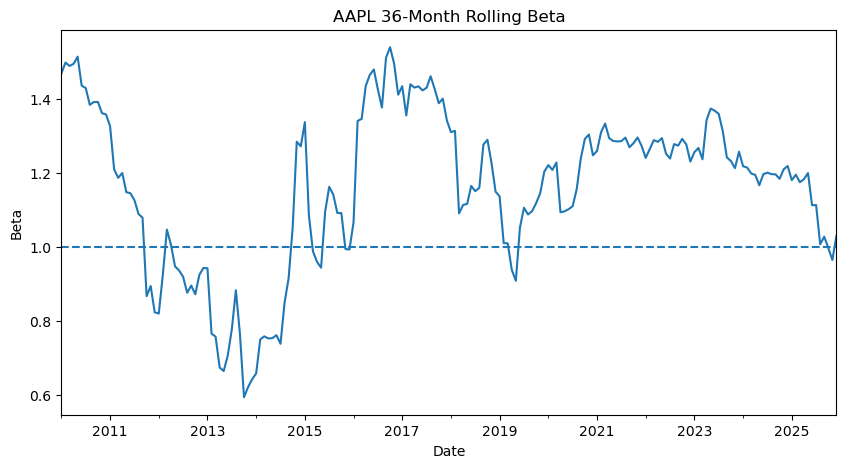

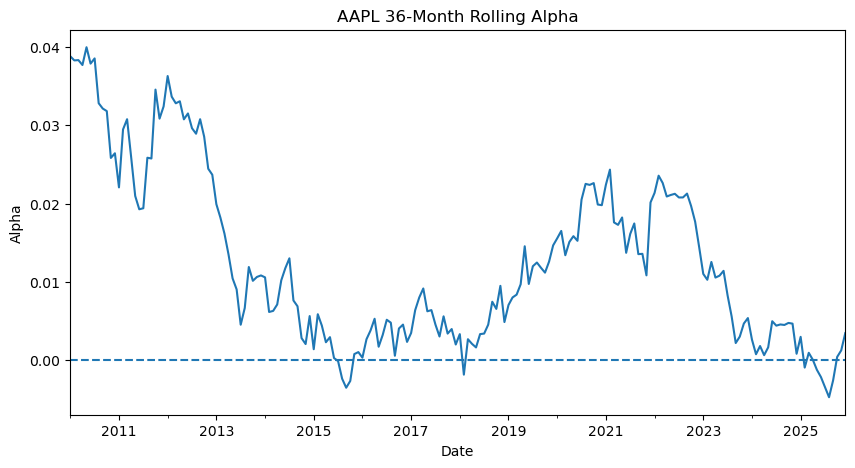

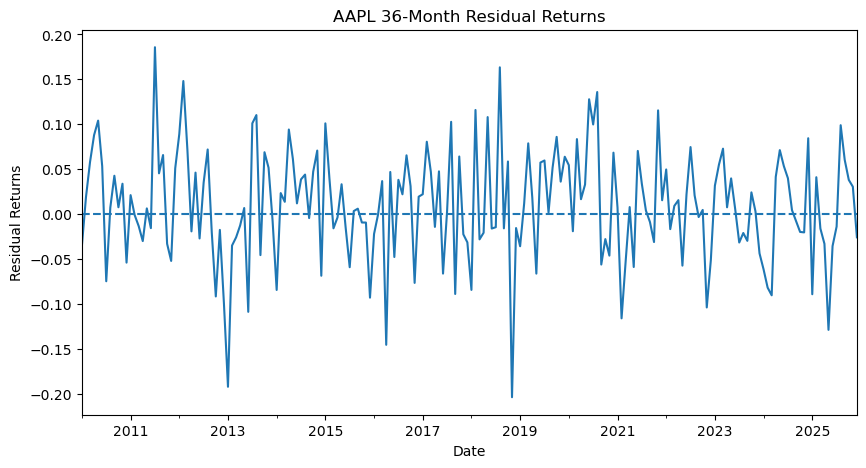

In [27]:
study_returns = monthly_returns.loc[
    "2010-01-01":"2025-12-31"
].copy()

stock_returns = study_returns[stocks]
benchmark_returns = study_returns["SPY"]


def calculate_rolling_residual_metrics(
    monthly_returns,
    stocks,
    benchmark="SPY",
    window=36,
    start_date="2010-01-01",
    end_date="2025-12-31"
):
    """
    Calculate rolling alpha, rolling beta, and realized residual returns
    relative to a benchmark.

    For each month t, alpha and beta are estimated using only the previous
    `window` months of data. Those estimates are then applied to month t
    to calculate the realized residual return.

    Parameters
    ----------
    monthly_returns : pd.DataFrame
        Monthly returns containing both stocks and benchmark.

    stocks : list
        List of stock ticker symbols.

    benchmark : str
        Benchmark ticker column in monthly_returns.

    window : int
        Number of prior months used to estimate alpha and beta.

    start_date : str
        Beginning of the study period.

    end_date : str
        End of the study period.

    Returns
    -------
    rolling_alpha : pd.DataFrame
        Rolling alpha estimates for each stock.

    rolling_beta : pd.DataFrame
        Rolling beta estimates for each stock.

    residual_returns : pd.DataFrame
        Monthly residual returns calculated using only information
        available before each realized return.

    residual_summary : pd.DataFrame
        Residual variance and residual volatility for each stock
        over the study period.
    """

    rolling_alpha = pd.DataFrame(
        index=monthly_returns.index,
        columns=stocks,
        dtype=float
    )

    rolling_beta = pd.DataFrame(
        index=monthly_returns.index,
        columns=stocks,
        dtype=float
    )

    residual_returns = pd.DataFrame(
        index=monthly_returns.index,
        columns=stocks,
        dtype=float
    )

    # Loop through each month
    for t in range(window, len(monthly_returns)):

        current_date = monthly_returns.index[t]

        # Use ONLY the previous `window` months
        estimation_window = monthly_returns.iloc[t-window:t]

        benchmark_hist = estimation_window[benchmark]

        # Current month's benchmark return
        benchmark_current = monthly_returns.iloc[t][benchmark]

        for ticker in stocks:

            stock_hist = estimation_window[ticker]

            # Combine stock and benchmark history and remove missing values
            hist_data = pd.concat(
                [stock_hist, benchmark_hist],
                axis=1
            ).dropna()

            hist_data.columns = ["Stock", "Benchmark"]

            # Require the full estimation window
            if len(hist_data) < window:
                continue

            benchmark_variance = hist_data["Benchmark"].var()

            # Avoid division by zero
            if benchmark_variance == 0:
                continue

            # Rolling beta
            beta = (
                hist_data["Stock"].cov(hist_data["Benchmark"])
                / benchmark_variance
            )

            # Rolling alpha
            alpha = (
                hist_data["Stock"].mean()
                - beta * hist_data["Benchmark"].mean()
            )

            rolling_alpha.loc[current_date, ticker] = alpha
            rolling_beta.loc[current_date, ticker] = beta

            # Current realized stock return
            stock_current = monthly_returns.loc[
                current_date,
                ticker
            ]

            # Skip if current data is missing
            if pd.isna(stock_current) or pd.isna(benchmark_current):
                continue

            # Return predicted by information available BEFORE current month
            theta = (
                stock_current
                - beta * benchmark_current
            )

            residual_returns.loc[current_date, ticker] = theta

    # Restrict outputs to study period
    rolling_alpha = rolling_alpha.loc[
        start_date:end_date
    ]

    rolling_beta = rolling_beta.loc[
        start_date:end_date
    ]

    residual_returns = residual_returns.loc[
        start_date:end_date
    ]

    # Summary residual statistics
    residual_summary = pd.DataFrame({
        "Residual Variance": residual_returns.var(),
        "Residual Volatility": residual_returns.std()
    })

    residual_summary.index.name = "Ticker"

    return (
        rolling_alpha,
        rolling_beta,
        residual_returns,
        residual_summary
    )


rolling_alpha, rolling_beta, residual_returns, residual_summary = (
    calculate_rolling_residual_metrics(
        monthly_returns=monthly_returns,
        stocks=stocks,
        benchmark="SPY",
        window=36,
        start_date="2010-01-01",
        end_date="2025-12-31"
    )
)


# Time-series volatility of each stock's signal
momentum_signal_vol = momentum_z.std(axis=0)
value_signal_vol = value_z.std(axis=0)


# Combine residual volatility with signal volatility
signal_volatility = pd.DataFrame({
    "Residual Volatility":
        residual_summary["Residual Volatility"],

    "Momentum Signal Volatility":
        momentum_signal_vol,

    "Value Signal Volatility":
        value_signal_vol
})


signal_volatility

rolling_beta["AAPL"].plot(
    figsize=(10, 5),
    title="AAPL 36-Month Rolling Beta"
)

plt.axhline(1, linestyle="--")
plt.ylabel("Beta")
plt.show()

rolling_alpha["AAPL"].plot(
    figsize=(10, 5),
    title="AAPL 36-Month Rolling Alpha"
)

plt.axhline(0, linestyle="--")
plt.ylabel("Alpha")
plt.show()

residual_returns["AAPL"].plot(
    figsize=(10, 5),
    title="AAPL 36-Month Residual Returns"
)

plt.axhline(0, linestyle="--")
plt.ylabel("Residual Returns")
plt.show()

## 5. Testing Whether Residual Volatility Is Embedded in the Signals

We now test whether stocks with greater residual return volatility also tend to have more volatile signal scores through time.

For each stock $i$, we have already calculated:

$$
\omega_i
=
Std_t(\theta_{i,t}),
$$

where $\omega_i$ is the stock's residual return volatility relative to SPY.

We have also calculated the time-series volatility of each stock's cross-sectional signal scores:

$$
\sigma^{MOM}_i
=
Std_t(z^{MOM}_{i,t})
$$

and

$$
\sigma^{VAL}_i
=
Std_t(z^{VAL}_{i,t}).
$$

We estimate two cross-sectional regressions.

For momentum:

$$
\sigma^{MOM}_i
=
a_M+b_M\omega_i+\epsilon_i.
$$

For value:

$$
\sigma^{VAL}_i
=
a_V+b_V\omega_i+\epsilon_i.
$$

The key null hypothesis for each signal is:

$$
H_0:b=0.
$$

Under the null hypothesis, residual return volatility has no linear relationship with the time-series volatility of the signal.

The alternative hypothesis is:

$$
H_A:b\neq0.
$$

Three regression outputs are particularly important:

### Slope coefficient $b$

The slope tells us the direction and magnitude of the relationship between residual volatility and signal volatility.

If

$$
b>0,
$$

stocks with greater residual volatility tend to have more volatile signal scores.

### $t$-statistic and $p$-value

The $t$-statistic tests whether the estimated slope is sufficiently far from zero relative to its estimation uncertainty:

$$
t_b
=
\frac{\hat b}{SE(\hat b)}.
$$

A small p-value provides evidence against $H_0:b=0$.

### $R^2$

The $R^2$ measures how much of the cross-sectional variation in signal volatility can be explained by residual return volatility.

For example,

$$
R^2=0.50
$$

would mean that approximately 50% of the differences in signal volatility across stocks are explained by their differences in residual volatility.

The goal is not merely to determine whether $b$ is statistically significant. We also want to determine whether the relationship is economically strong enough to suggest that residual volatility is already embedded in the signal.

                                OLS Regression Results                                
Dep. Variable:     Momentum Signal Volatility   R-squared:                       0.923
Model:                                    OLS   Adj. R-squared:                  0.920
Method:                         Least Squares   F-statistic:                     334.0
Date:                        Tue, 18 Aug 2026   Prob (F-statistic):           4.25e-17
Time:                                16:39:09   Log-Likelihood:                 22.844
No. Observations:                          30   AIC:                            -41.69
Df Residuals:                              28   BIC:                            -38.89
Df Model:                                   1                                         
Covariance Type:                    nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------

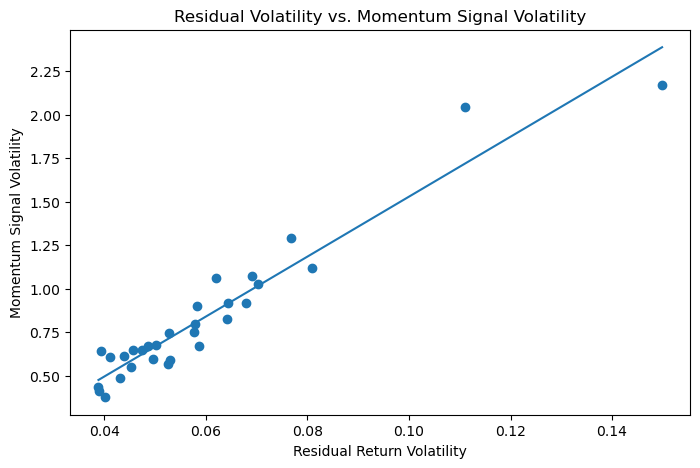

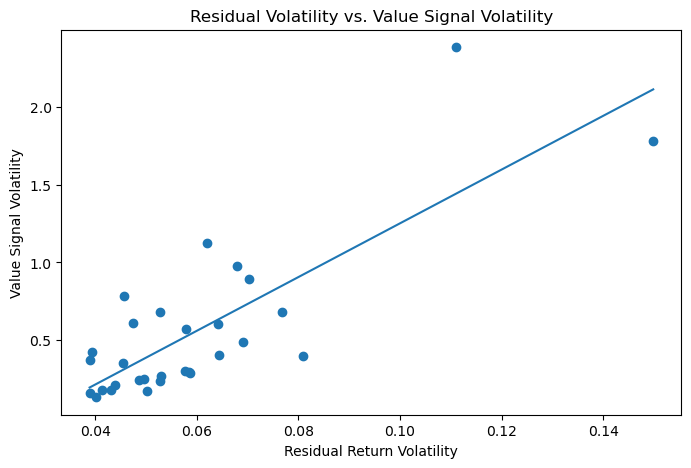

In [28]:
# Explanatory variable
X = signal_volatility["Residual Volatility"]

# Add intercept a
X = sm.add_constant(X)

# Dependent variable
y_momentum = signal_volatility["Momentum Signal Volatility"]

# Estimate regression
momentum_reg = sm.OLS(y_momentum, X).fit()

print(momentum_reg.summary())

y_value = signal_volatility["Value Signal Volatility"]

value_reg = sm.OLS(y_value, X).fit()

print(value_reg.summary())

plt.figure(figsize=(8, 5))

plt.scatter(
    signal_volatility["Residual Volatility"],
    signal_volatility["Momentum Signal Volatility"]
)

x_line = np.linspace(
    signal_volatility["Residual Volatility"].min(),
    signal_volatility["Residual Volatility"].max(),
    100
)

y_line = (
    momentum_reg.params["const"]
    + momentum_reg.params["Residual Volatility"] * x_line
)

plt.plot(x_line, y_line)

plt.xlabel("Residual Return Volatility")
plt.ylabel("Momentum Signal Volatility")
plt.title("Residual Volatility vs. Momentum Signal Volatility")

plt.show()

plt.figure(figsize=(8, 5))

plt.scatter(
    signal_volatility["Residual Volatility"],
    signal_volatility["Value Signal Volatility"]
)

y_line = (
    value_reg.params["const"]
    + value_reg.params["Residual Volatility"] * x_line
)

plt.plot(x_line, y_line)

plt.xlabel("Residual Return Volatility")
plt.ylabel("Value Signal Volatility")
plt.title("Residual Volatility vs. Value Signal Volatility")

plt.show()

In [29]:
# Rerunning but removing outliers

signal_volatility.sort_values(
    "Residual Volatility",
    ascending=False
).head(10)

# Identify stock with highest residual volatility
highest_vol_stock = signal_volatility[
    "Residual Volatility"
].idxmax()

print("Removed stock:", highest_vol_stock)

# Create robustness sample
robust_sample = signal_volatility.drop(
    index=highest_vol_stock
)

X_robust = sm.add_constant(
    robust_sample["Residual Volatility"]
)

y_momentum_robust = robust_sample[
    "Momentum Signal Volatility"
]

momentum_reg_robust = sm.OLS(
    y_momentum_robust,
    X_robust
).fit()

print(momentum_reg_robust.summary())

y_value_robust = robust_sample[
    "Value Signal Volatility"
]

value_reg_robust = sm.OLS(
    y_value_robust,
    X_robust
).fit()

print(value_reg_robust.summary())

Removed stock: NFLX
                                OLS Regression Results                                
Dep. Variable:     Momentum Signal Volatility   R-squared:                       0.911
Model:                                    OLS   Adj. R-squared:                  0.908
Method:                         Least Squares   F-statistic:                     278.1
Date:                        Tue, 18 Aug 2026   Prob (F-statistic):           9.66e-16
Time:                                16:39:10   Log-Likelihood:                 26.493
No. Observations:                          29   AIC:                            -48.99
Df Residuals:                              27   BIC:                            -46.25
Df Model:                                   1                                         
Covariance Type:                    nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------

# Part 2: Information Coefficient

The next step is to test whether our momentum and value signals contain information about future residual returns.

For each month $t$, we calculate a cross-sectional Information Coefficient:

$$
IC_t
=
Corr_i
\left(
z_{i,t},
\theta_{i,t+1}
\right)
$$

where:

- $z_{i,t}$ is the standardized signal for stock $i$ at the end of month $t$.
- $\theta_{i,t+1}$ is the realized residual return for stock $i$ during the following month.
- The correlation is calculated across stocks $i$ at a single point in time.

For example, the signal scores observed at the end of January are compared with the residual returns realized during February.

The IC therefore measures whether stocks ranked more favorably by the signal subsequently earn higher residual returns than stocks ranked less favorably.

We calculate a separate IC time series for momentum and value:

$$
IC^{MOM}_1, IC^{MOM}_2, \ldots, IC^{MOM}_T
$$

and

$$
IC^{VAL}_1, IC^{VAL}_2, \ldots, IC^{VAL}_T.
$$

After constructing these time series, we will study their average level, variability, and statistical uncertainty.

## 2.1 Constructing the Monthly IC Time Series

For each month $t$, we compare the cross-sectional signal values with the next month's realized residual returns.

Because our eventual strategy is based on ranking stocks, we use the **Spearman rank correlation** as our primary Information Coefficient:

$$
IC_t
=
Corr^{Spearman}_i
\left(
z_{i,t},
\theta_{i,t+1}
\right)
$$

The calculation proceeds in two steps:

1. Shift realized residual returns backward one row so that $\theta_{i,t+1}$ is aligned with $z_{i,t}$.
2. For each month, calculate the Spearman correlation across stocks.

This produces one IC observation per month for each signal.

In [30]:
from scipy.stats import spearmanr
import pandas as pd


def calculate_monthly_ic(signal_scores, residual_returns):
    """
    Calculate monthly cross-sectional Spearman ICs.

    Parameters
    ----------
    signal_scores : pd.DataFrame
        Rows = months
        Columns = stocks
        Values = cross-sectional standardized signal scores z_(i,t)

    residual_returns : pd.DataFrame
        Rows = months
        Columns = stocks
        Values = realized residual returns theta_(i,t)

    Returns
    -------
    pd.Series
        Monthly Spearman IC values.
    """

    # Align next month's residual return with this month's signal
    future_residual_returns = residual_returns.shift(-1)

    monthly_ic = {}

    for date in signal_scores.index:

        signal = signal_scores.loc[date]
        future_theta = future_residual_returns.loc[date]

        # Keep only stocks for which both observations exist
        valid = signal.notna() & future_theta.notna()

        signal = signal[valid]
        future_theta = future_theta[valid]

        # Need at least two observations to calculate a correlation
        if len(signal) >= 2:
            ic, _ = spearmanr(signal, future_theta)
            monthly_ic[date] = ic

    return pd.Series(monthly_ic, name="IC")


momentum_ic = calculate_monthly_ic(
    signal_scores=momentum_z,
    residual_returns=residual_returns
)

value_ic = calculate_monthly_ic(
    signal_scores=value_z,
    residual_returns=residual_returns
)

#pandas checking
ticker = "AAPL"

alignment_check = pd.DataFrame({
    "Signal_t": momentum_z[ticker],
    "Theta_t": residual_returns[ticker],
    "Theta_t_plus_1": residual_returns[ticker].shift(-1)
})

display(alignment_check.loc["2015-01-01":"2015-03-31"])
print("Shifted value:")
print(residual_returns[ticker].shift(-1).loc["2015-01-31"])

print("\nActual next-month value:")
print(residual_returns[ticker].loc["2015-02-28"])


print("\nMomentum IC:")
display(momentum_ic.head())

print("Value IC:")
display(value_ic.head())

,Signal_t,Theta_t,Theta_t_plus_1
Date,,,
2015-01-31,2.158836,0.101018,0.039845
2015-02-28,2.677345,0.039845,-0.015860
2015-03-31,2.796721,-0.015860,-0.003647


Shifted value:
0.03984498539230095

Actual next-month value:
0.03984498539230095

Momentum IC:


2010-01-31    0.204004
2010-02-28    0.019800
2010-03-31   -0.132814
2010-04-30    0.310345
2010-05-31   -0.100779
Name: IC, dtype: float64

Value IC:


2010-01-31    0.145717
2010-02-28   -0.463849
2010-03-31   -0.205339
2010-04-30   -0.096329
2010-05-31    0.160845
Name: IC, dtype: float64

## 2.2 IC Summary Statistics

A signal's average IC measures its estimated forecasting skill, but the mean alone does not tell us how reliably that skill has been estimated.

For each signal, we therefore calculate:

**Mean IC**

$$
\bar{IC}
=
\frac{1}{T}\sum_{t=1}^{T}IC_t
$$

**IC volatility**

$$
\sigma_{IC}
=
Std(IC_t)
$$

**Standard error of the mean IC**

$$
SE(\bar{IC})
=
\frac{\sigma_{IC}}{\sqrt{T}}
$$

**IC t-statistic**

$$
t_{IC}
=
\frac{\bar{IC}}{SE(\bar{IC})}
$$

The mean IC measures the estimated magnitude of forecasting skill, while the standard error measures our uncertainty about that estimate. The t-statistic measures the estimated mean IC relative to its uncertainty.

In [31]:
import numpy as np
import pandas as pd


def summarize_ic(ic_series):
    """
    Calculate summary statistics for a monthly IC series.
    """

    ic = ic_series.dropna()

    T = len(ic)
    mean_ic = ic.mean()
    ic_volatility = ic.std(ddof=1)
    se_mean_ic = ic_volatility / np.sqrt(T)
    t_stat = mean_ic / se_mean_ic

    return pd.Series({
        "Mean IC": mean_ic,
        "IC Volatility": ic_volatility,
        "Observations": T,
        "SE Mean IC": se_mean_ic,
        "t-statistic": t_stat
    })

ic_summary = pd.DataFrame({
    "Momentum": summarize_ic(momentum_ic),
    "Value": summarize_ic(value_ic)
})

display(ic_summary)

,Momentum,Value
Mean IC,0.008248,-0.048467
IC Volatility,0.282972,0.286419
Observations,191.000000,191.000000
SE Mean IC,0.020475,0.020725
t-statistic,0.402814,-2.338620


## 2.3 Testing for IC Persistence

The standard error used above,

$$
SE(\bar{IC}) = \frac{\sigma_{IC}}{\sqrt{T}}
$$

is most appropriate when the monthly IC observations provide approximately independent information.

Because IC is a time series, we should test whether forecasting performance persists from one month to the next.

We begin with the lag-1 autocorrelation:

$$
\rho_1 = Corr(IC_t, IC_{t-1})
$$

This measures whether a high IC in one month tends to be followed by a high IC in the next month.

Interpretation:

- $\rho_1 > 0$ indicates positive persistence.
- $\rho_1 < 0$ indicates reversal.
- $\rho_1 \approx 0$ indicates little linear relationship between consecutive monthly ICs.

We then estimate an AR(1) regression:

$$
IC_t = c + \phi IC_{t-1} + u_t
$$

where $\phi$ measures the relationship between the previous month's IC and the current month's IC.

We test:

$$
H_0: \phi = 0
$$

against:

$$
H_1: \phi \neq 0
$$

If we reject $H_0$, there is evidence that consecutive monthly ICs are serially related. We examine the estimated coefficient $\phi$, its t-statistic and p-value, and the regression $R^2$.

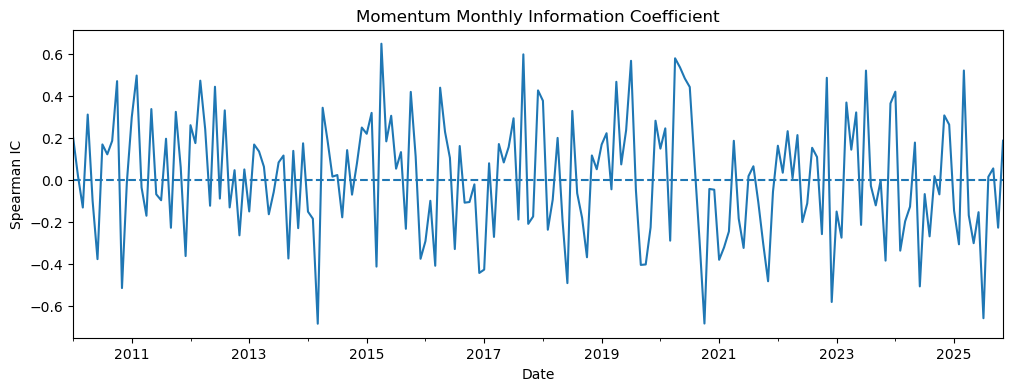

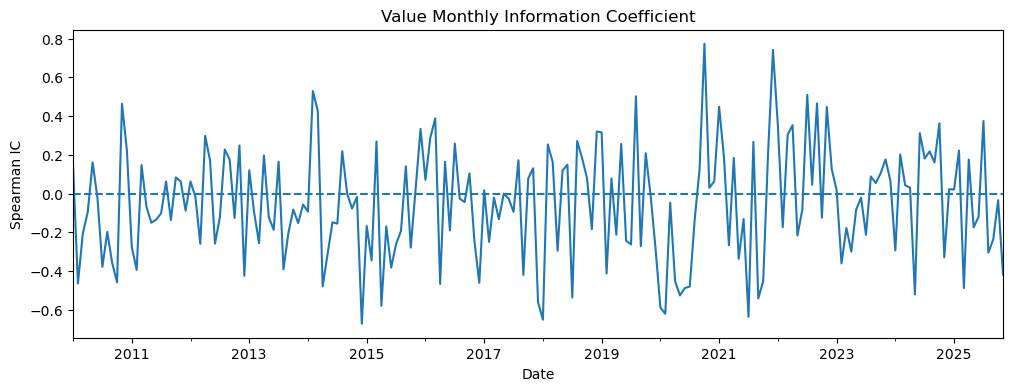

In [32]:
import matplotlib.pyplot as plt

momentum_ic.plot(
    figsize=(12, 4),
    title="Momentum Monthly Information Coefficient"
)

plt.axhline(0, linestyle="--")
plt.ylabel("Spearman IC")
plt.xlabel("Date")
plt.show()

value_ic.plot(
    figsize=(12, 4),
    title="Value Monthly Information Coefficient"
)

plt.axhline(0, linestyle="--")
plt.ylabel("Spearman IC")
plt.xlabel("Date")
plt.show()

In [33]:
momentum_ic_autocorr = momentum_ic.autocorr(lag=1)
value_ic_autocorr = value_ic.autocorr(lag=1)

print(f"Momentum lag-1 autocorrelation: {momentum_ic_autocorr:.4f}")
print(f"Value lag-1 autocorrelation:    {value_ic_autocorr:.4f}")

import statsmodels.api as sm


def run_ic_ar1(ic_series):
    """
    Run an AR(1) regression:

        IC_t = c + phi * IC_(t-1) + u_t
    """

    ic = ic_series.dropna()

    ar_data = pd.DataFrame({
        "IC_t": ic,
        "IC_t_minus_1": ic.shift(1)
    }).dropna()

    X = sm.add_constant(ar_data["IC_t_minus_1"])
    y = ar_data["IC_t"]

    model = sm.OLS(y, X).fit()

    return model

momentum_ar1 = run_ic_ar1(momentum_ic)
value_ar1 = run_ic_ar1(value_ic)

print("Momentum IC AR(1)")
print(momentum_ar1.summary())

print("\nValue IC AR(1)")
print(value_ar1.summary())

Momentum lag-1 autocorrelation: 0.0021
Value lag-1 autocorrelation:    0.0313
Momentum IC AR(1)
                            OLS Regression Results                            
Dep. Variable:                   IC_t   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                 0.0007910
Date:                Tue, 18 Aug 2026   Prob (F-statistic):              0.978
Time:                        16:39:10   Log-Likelihood:                -29.500
No. Observations:                 190   AIC:                             63.00
Df Residuals:                     188   BIC:                             69.49
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

### Checking Dependence Across Multiple Lags

The AR(1) regression tests whether the current month's IC is related to the immediately preceding month's IC:

$$
IC_t = c + \phi IC_{t-1} + u_t
$$

For both momentum and value, the coefficient on $IC_{t-1}$ was statistically insignificant, providing no evidence of lag-1 serial correlation.

However, the absence of lag-1 correlation does not guarantee that ICs are unrelated at longer lags. For example, it is possible that $IC_t$ is unrelated to $IC_{t-1}$ but related to $IC_{t-2}$ or $IC_{t-3}$.

To examine serial correlation across multiple lags, we use the **autocorrelation function (ACF)**:

$$
\rho_k = Corr(IC_t, IC_{t-k})
$$

where $k$ represents the number of months separating the observations.

For example:

$$
\rho_1 = Corr(IC_t, IC_{t-1})
$$

measures one-month dependence, while

$$
\rho_6 = Corr(IC_t, IC_{t-6})
$$

measures whether ICs six months apart are correlated.

We examine the ACF across several monthly lags to determine whether there is evidence of longer-term serial dependence in signal forecasting performance.

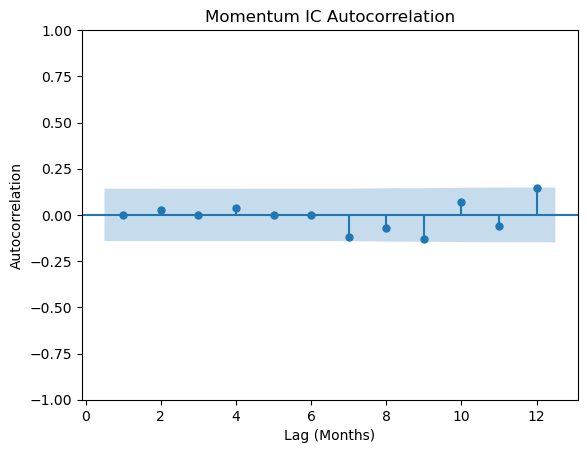

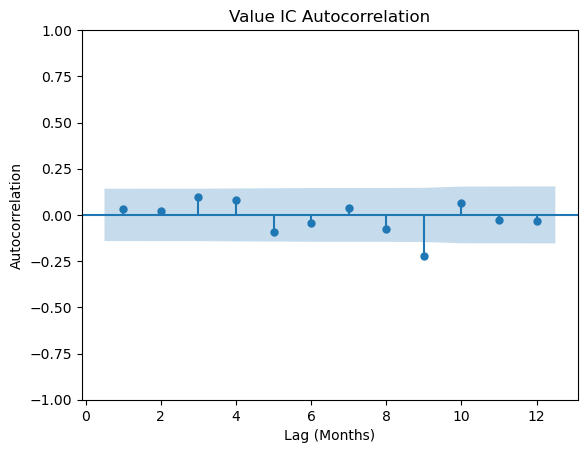

In [34]:
## ACF Test
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(
    momentum_ic.dropna(),
    lags=12,
    zero=False
)

plt.title("Momentum IC Autocorrelation")
plt.xlabel("Lag (Months)")
plt.ylabel("Autocorrelation")
plt.show()

plot_acf(
    value_ic.dropna(),
    lags=12,
    zero=False
)

plt.title("Value IC Autocorrelation")
plt.xlabel("Lag (Months)")
plt.ylabel("Autocorrelation")
plt.show()

### Joint Test for Serial Correlation

The ACF examines individual autocorrelations at different lags. Because we examine several lags simultaneously, an individual autocorrelation may appear significant by chance.

We therefore also use the Ljung-Box test to examine whether a group of autocorrelations is jointly different from zero.

For $K$ lags, the null hypothesis is:

$$
H_0: \rho_1 = \rho_2 = \cdots = \rho_K = 0
$$

against the alternative:

$$
H_1: \text{at least one } \rho_k \neq 0
$$

Failing to reject the null would indicate that we do not have sufficient evidence of serial correlation across the tested lags.

In [35]:
from statsmodels.stats.diagnostic import acorr_ljungbox

momentum_lb = acorr_ljungbox(
    momentum_ic.dropna(),
    lags=[12],
    return_df=True
)

value_lb = acorr_ljungbox(
    value_ic.dropna(),
    lags=[12],
    return_df=True
)

print("Momentum Ljung-Box Test:")
display(momentum_lb)

print("Value Ljung-Box Test:")
display(value_lb)

Momentum Ljung-Box Test:


,lb_stat,lb_pvalue
12,13.880291,0.308418


Value Ljung-Box Test:


,lb_stat,lb_pvalue
12,18.325764,0.106151


### IC Persistence Results

Neither momentum nor value exhibits statistically significant lag-1 autocorrelation in the AR(1) regressions.

The ACF plots also show little systematic serial dependence across the first 12 monthly lags. Although value displays a relatively large negative autocorrelation at one lag, there is no broad pattern of persistent autocorrelation.

The Ljung-Box tests at 12 lags produce p-values above 0.05 for both momentum and value. We therefore fail to reject the null hypothesis that the first 12 autocorrelations are jointly zero.

Overall, we find little evidence of meaningful serial dependence in the monthly IC series. This supports using the conventional standard error,

$$
SE(\bar{IC}) = \frac{\sigma_{IC}}{\sqrt{T}},
$$

as a reasonable estimate of uncertainty for the mean IC in this analysis.

## 2.4 Part 2 Conclusion

The monthly cross-sectional IC analysis measures whether momentum and value signals successfully rank stocks according to subsequent residual returns.

Momentum produced a small positive average Spearman IC, but the estimate was economically weak and statistically indistinguishable from zero.

Value produced a negative average Spearman IC, indicating that stocks with high value scores — stocks with poor long-term historical performance — tended to continue underperforming rather than reverse over the following month.

Tests of serial dependence, including AR(1), the autocorrelation function, and the Ljung-Box test, found little evidence of systematic persistence in the monthly IC series.

These results characterize the forecasting ability and uncertainty of the signals.

Grinold & Kahn Bayesian shrinkage is not applied directly to the IC. Instead, the IC helps determine the amount of shrinkage applied to the estimated forecasting coefficient in a regression of the form

$$
\theta(t) = b\,g(t) + \epsilon(t).
$$

We therefore postpone Bayesian shrinkage until the forecasting coefficient $b$ is explicitly estimated.

# Part 3: Constructing Factor Portfolios

The momentum and value z-scores constructed earlier are stock-level signals. They are not themselves factor returns.

We now use these signals to construct factor-mimicking long-short portfolios.

At the end of each month $t$, stocks are ranked according to their cross-sectional signal values and divided into three groups:

- Top tercile: long
- Middle tercile: ignored
- Bottom tercile: short

Stocks are equally weighted within each portfolio leg.

For momentum, the realized factor return during the following month is:

$$
F^{MOM}_{t+1}
=
R^{MOM,High}_{t+1}
-
R^{MOM,Low}_{t+1}
$$

For value:

$$
F^{VAL}_{t+1}
=
R^{VAL,High}_{t+1}
-
R^{VAL,Low}_{t+1}
$$

The timing remains consistent with the forecasting framework used for the Information Coefficient:

$$
z_{i,t}
\rightarrow
\text{portfolio formation at }t
\rightarrow
\text{return realized during }t+1.
$$

These factor returns measure the realized performance of portfolios designed to capture the information contained in each signal.

In [36]:
import pandas as pd
import numpy as np


def construct_factor_returns(signal_scores, residual_returns):
    """
    Construct rolling long-short factor returns with no look-ahead bias.

    At month t:
        - use signal z_(i,t) to form portfolios

    At month t+1:
        - observe residual returns theta_(i,t+1)
        - record the factor return using the t+1 date
    """

    factor_results = []

    # Work only over dates that exist in both objects
    common_dates = signal_scores.index.intersection(residual_returns.index)

    signal_scores = signal_scores.loc[common_dates].sort_index()
    residual_returns = residual_returns.loc[common_dates].sort_index()

    for i in range(len(common_dates) - 1):

        formation_date = common_dates[i]
        return_date = common_dates[i + 1]

        signal = signal_scores.loc[formation_date]
        theta_next = residual_returns.loc[return_date]

        # Keep only stocks with both formation-period signal
        # and next-period realized residual return
        valid = signal.notna() & theta_next.notna()

        signal = signal[valid]
        theta_next = theta_next[valid]

        if len(signal) < 3:
            continue

        lower_cutoff = signal.quantile(1 / 3)
        upper_cutoff = signal.quantile(2 / 3)

        low_stocks = signal[signal <= lower_cutoff].index
        high_stocks = signal[signal >= upper_cutoff].index

        high_return = theta_next.loc[high_stocks].mean()
        low_return = theta_next.loc[low_stocks].mean()

        factor_return = high_return - low_return

        factor_results.append({
            "Date": return_date,
            "Formation Date": formation_date,
            "High Return": high_return,
            "Low Return": low_return,
            "Factor Return": factor_return,
            "N High": len(high_stocks),
            "N Low": len(low_stocks)
        })

    return pd.DataFrame(factor_results).set_index("Date")

momentum_factor = construct_factor_returns(
    signal_scores=momentum_z,
    residual_returns=residual_returns
)

value_factor = construct_factor_returns(
    signal_scores=value_z,
    residual_returns=residual_returns
)

print("Momentum Factor:")
display(momentum_factor.head())

print("Value Factor:")
display(value_factor.head())

Momentum Factor:


,Formation Date,High Return,Low Return,Factor Return,N High,N Low
Date,,,,,,
2010-02-28,2010-01-31,-0.013793,-0.009413,-0.004380,10,10
2010-03-31,2010-02-28,0.014250,0.001621,0.012628,10,10
2010-04-30,2010-03-31,-0.002901,0.014527,-0.017428,10,10
2010-05-31,2010-04-30,0.026553,-0.006553,0.033106,10,10
2010-06-30,2010-05-31,-0.027495,0.009331,-0.036825,10,10


Value Factor:


,Formation Date,High Return,Low Return,Factor Return,N High,N Low
Date,,,,,,
2010-02-28,2010-01-31,0.004796,-0.028221,0.033017,10,10
2010-03-31,2010-02-28,-0.012031,0.032666,-0.044697,10,10
2010-04-30,2010-03-31,0.003390,0.046034,-0.042644,10,10
2010-05-31,2010-04-30,-0.000398,0.029669,-0.030067,10,10
2010-06-30,2010-05-31,0.003820,-0.017282,0.021102,10,10


## 3.2 Factor Return Performance

We now have realized monthly return series for the momentum and value factor portfolios:

$$
F^{MOM}_t
$$

and

$$
F^{VAL}_t.
$$

Each factor return represents the realized residual return of the high-signal portfolio minus the realized residual return of the low-signal portfolio:

$$
F_t = R^{High}_t - R^{Low}_t.
$$

We first examine the average monthly factor return:

$$
\bar{F}
=
\frac{1}{T}\sum_{t=1}^{T}F_t.
$$

A positive average factor return indicates that, on average, the high-signal stocks outperformed the low-signal stocks in residual-return terms.

We also calculate factor volatility:

$$
\sigma_F = Std(F_t),
$$

and the standard error of the average factor return:

$$
SE(\bar{F})
=
\frac{\sigma_F}{\sqrt{T}}.
$$

The corresponding t-statistic is:

$$
t_F
=
\frac{\bar{F}}{SE(\bar{F})}.
$$

This allows us to distinguish between the economic magnitude of the realized factor return and the statistical uncertainty surrounding its estimated average.

,Momentum,Value
Mean Monthly Return,0.000924,-0.006639
Monthly Volatility,0.041412,0.045087
Observations,191.000000,191.000000
SE Mean Return,0.002996,0.003262
t-statistic,0.308525,-2.035013


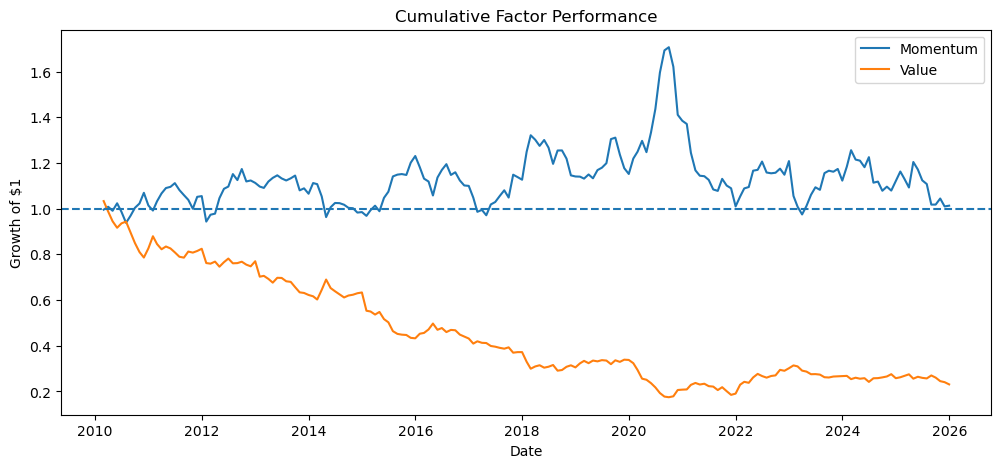

In [37]:
def summarize_factor_returns(factor_data):
    """
    Summarize a monthly long-short factor return series.
    """

    factor_returns = factor_data["Factor Return"].dropna()

    T = len(factor_returns)
    mean_return = factor_returns.mean()
    volatility = factor_returns.std(ddof=1)
    se_mean = volatility / np.sqrt(T)
    t_stat = mean_return / se_mean

    return pd.Series({
        "Mean Monthly Return": mean_return,
        "Monthly Volatility": volatility,
        "Observations": T,
        "SE Mean Return": se_mean,
        "t-statistic": t_stat
    })


factor_summary = pd.DataFrame({
    "Momentum": summarize_factor_returns(momentum_factor),
    "Value": summarize_factor_returns(value_factor)
})

display(factor_summary)

momentum_cumulative = (
    1 + momentum_factor["Factor Return"]
).cumprod()

value_cumulative = (
    1 + value_factor["Factor Return"]
).cumprod()

plt.figure(figsize=(12, 5))

plt.plot(
    momentum_cumulative.index,
    momentum_cumulative,
    label="Momentum"
)

plt.plot(
    value_cumulative.index,
    value_cumulative,
    label="Value"
)

plt.axhline(1, linestyle="--")

plt.title("Cumulative Factor Performance")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()

plt.show()

## 3.3 Relationship Between Momentum and Value Factor Returns

After constructing the momentum and value factor portfolios, we examine whether the two factors capture similar or distinct patterns in residual returns.

We first calculate the correlation between their realized monthly factor returns:

$$
\rho_{MOM,VAL}
=
Corr(F_t^{MOM},F_t^{VAL})
$$

A positive correlation indicates that momentum and value factor returns tend to move in the same direction.

A negative correlation indicates that the factors tend to move in opposite directions.

A correlation near zero indicates little linear relationship between their realized factor returns.

We then estimate the regression:

$$
F_t^{MOM}
=
c
+
\beta_{MOM,VAL}F_t^{VAL}
+
\epsilon_t
$$

where $\beta_{MOM,VAL}$ measures the sensitivity of momentum factor returns to value factor returns.

The regression allows us to examine:

- $\beta$: the direction and magnitude of the relationship between factor returns.
- t-statistic and p-value: whether the estimated relationship is statistically distinguishable from zero.
- $R^2$: the proportion of variation in momentum factor returns associated with variation in value factor returns.

This analysis helps determine whether the two signal-based portfolios capture overlapping or relatively distinct patterns in residual returns.

Momentum-Value Factor Correlation: -0.4352


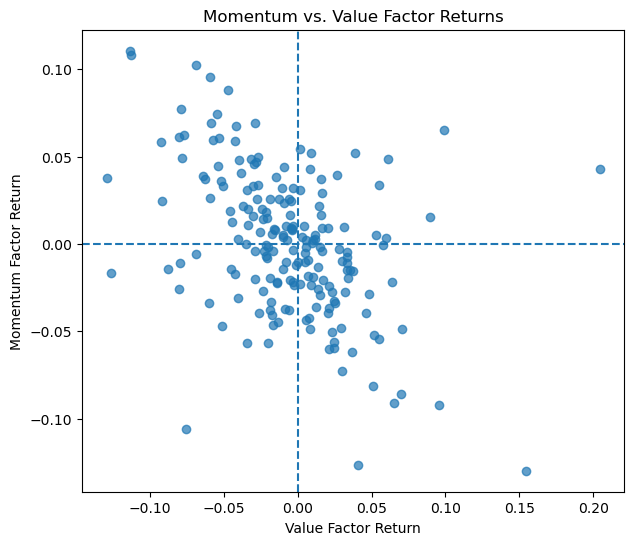

                            OLS Regression Results                            
Dep. Variable:               Momentum   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     44.15
Date:                Tue, 18 Aug 2026   Prob (F-statistic):           3.15e-10
Time:                        16:39:11   Log-Likelihood:                 357.72
No. Observations:                 191   AIC:                            -711.4
Df Residuals:                     189   BIC:                            -704.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0017      0.003     -0.632      0.5

In [38]:
factor_returns = pd.DataFrame({
    "Momentum": momentum_factor["Factor Return"],
    "Value": value_factor["Factor Return"]
}).dropna()

factor_correlation = factor_returns["Momentum"].corr(
    factor_returns["Value"]
)

print(f"Momentum-Value Factor Correlation: {factor_correlation:.4f}")

plt.figure(figsize=(7, 6))

plt.scatter(
    factor_returns["Value"],
    factor_returns["Momentum"],
    alpha=0.7
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Value Factor Return")
plt.ylabel("Momentum Factor Return")
plt.title("Momentum vs. Value Factor Returns")

plt.show()

import statsmodels.api as sm

X = factor_returns["Value"]
y = factor_returns["Momentum"]

X = sm.add_constant(X)

factor_relationship_model = sm.OLS(y, X).fit()

print(factor_relationship_model.summary())

## 3.4 Factor Covariance and Correlation

After examining the pairwise regression between momentum and value, we summarize their joint behavior using covariance and correlation matrices.

The covariance between two factor returns is

$$
Cov(F^{MOM},F^{VAL})
=
E\left[
(F^{MOM}-\bar F^{MOM})
(F^{VAL}-\bar F^{VAL})
\right].
$$

Covariance measures whether the two factor returns tend to move together in absolute return units.

Because covariance depends on the volatility of each factor, we also examine correlation:

$$
\rho_{MOM,VAL}
=
\frac{
Cov(F^{MOM},F^{VAL})
}{
\sigma_{MOM}\sigma_{VAL}
}.
$$

Correlation standardizes the covariance and therefore lies between $-1$ and $1$.

These matrices will become useful later when combining multiple factor forecasts because they describe how distinct or overlapping the factor return processes are.

In [39]:
factor_covariance = factor_returns.cov()
factor_correlation_matrix = factor_returns.corr()

print("Factor Covariance Matrix:")
display(factor_covariance)

print("Factor Correlation Matrix:")
display(factor_correlation_matrix)

Factor Covariance Matrix:


,Momentum,Value
Momentum,0.001715,-0.000813
Value,-0.000813,0.002033


Factor Correlation Matrix:


,Momentum,Value
Momentum,1.000000,-0.435176
Value,-0.435176,1.000000


## 3.5 Part 3 Conclusion

Momentum and value factor portfolios were constructed each month using the previous month's cross-sectional signal rankings and the following month's realized residual returns.

The momentum factor produced a small positive average monthly return, but the estimate was not statistically distinguishable from zero.

The value factor produced a negative average monthly return, indicating that the 60-month price-based reversal signal performed in the opposite direction from its intended reversal interpretation over this sample.

The two realized factor return series exhibit a moderate negative correlation:

$$
\rho_{MOM,VAL} \approx -0.435.
$$

A regression of momentum factor returns on value factor returns confirms that this negative relationship is statistically significant, while the regression $R^2$ of approximately $0.189$ indicates that the factors still contain substantial independent variation.

The factor covariance matrix summarizes their joint realized return behavior and will be useful when considering multiple factors together.

## Part 4: Signal Persistence and Information Horizon

So far, we have evaluated whether the momentum and value signals contain information about subsequent residual returns. We now extend this analysis by asking **how persistent the signals themselves are and how long the information contained in a signal remains useful**.

These are two distinct concepts:

1. **Signal persistence:** How similar is a signal today to the same signal in the previous month?
2. **Information decay:** How quickly does the predictive power of a signal decline as we attempt to forecast returns further into the future?

Together, these allow us to estimate the **information horizon** of each signal and determine whether past signals may contain useful information beyond what is contained in the most recent signal.

---

### 4.1 Signal Persistence

Let $s_{i,t}$ denote the standardized signal score for stock $i$ at time $t$. Signal persistence measures the relationship between consecutive observations of the signal.

We define the one-period signal correlation as

$$
\rho = \operatorname{Corr}(s_t,s_{t-1}).
$$

A large positive $\rho$ means that signal rankings change relatively slowly. Stocks with high scores this month tend to continue having high scores next month. A low $\rho$ means that the signal changes substantially from one period to the next.

This is distinct from the autocorrelation of the IC examined previously. The earlier analysis considered

$$
\operatorname{Corr}(IC_t,IC_{t-1}),
$$

which asks whether periods of strong or weak **forecasting performance** tend to persist.

Here, instead, we examine

$$
\operatorname{Corr}(s_t,s_{t-1}),
$$

which asks whether the **signal itself** persists.

For each signal, we will therefore estimate $\rho$ using consecutive monthly signal observations.

---

### 4.2 Information Decay

Signal persistence does not tell us how long the information contained in a signal remains useful. To investigate this, we examine the relationship between a signal observed at time $t$ and residual returns occurring progressively further into the future.

Recall that our realized residual return is denoted by $\theta$. Instead of examining only the usual one-period IC,

$$
IC_1 = \operatorname{Corr}(s_t,\theta_{t+1}),
$$

we calculate a sequence of forward ICs:

$$
IC_1 = \operatorname{Corr}(s_t,\theta_{t+1}),
$$

$$
IC_2 = \operatorname{Corr}(s_t,\theta_{t+2}),
$$

$$
IC_3 = \operatorname{Corr}(s_t,\theta_{t+3}),
$$

$$
\vdots
$$

$$
IC_k = \operatorname{Corr}(s_t,\theta_{t+k}).
$$

Importantly, the signal $s_t$ remains fixed while the return being predicted moves progressively further into the future.

For example,

$$
s_{\text{January}}
\rightarrow
\begin{cases}
\theta_{\text{February}} & IC_1 \
\theta_{\text{March}} & IC_2 \
\theta_{\text{April}} & IC_3 \
\theta_{\text{May}} & IC_4
\end{cases}
$$

This allows us to observe how the predictive information contained in the January signal decays as the forecast horizon increases.

---

### 4.3 The IC Decay Curve

If information gradually loses its forecasting power, Grinold and Kahn model the decay approximately as

$$
IC_k = IC_1\delta^{k-1},
$$

where $\delta$ is the **information decay factor**.

The parameter $\delta$ describes the fraction of the signal's predictive information that survives from one period to the next.

For example, if

$$
\delta = 0.80,
$$

then approximately 80% of the previous period's forecasting power survives into the next period:

$$
IC_2 = 0.80IC_1,
$$

$$
IC_3 = 0.80^2IC_1,
$$

$$
IC_4 = 0.80^3IC_1.
$$

A $\delta$ close to one therefore represents slowly decaying information, while a smaller $\delta$ represents information that becomes stale relatively quickly.

We will examine the empirical sequence

$$
IC_1,IC_2,\ldots,IC_k
$$

for both momentum and value to determine whether their predictive information exhibits a meaningful decay pattern.

---

### 4.4 Information Half-Life

The decay factor can be translated into a more intuitive quantity: the **information half-life**.

The half-life is the amount of time required for the forecasting power of a signal to decline to one-half of its initial value.

Grinold and Kahn relate the decay factor and half-life according to

$$
\delta =
\left(\frac{1}{2}\right)^{\Delta t/HL},
$$

or equivalently,

$$
HL =
-\frac{\Delta t\ln(2)}{\ln(\delta)}.
$$

Because our observations are monthly, it is convenient to express the half-life directly in months. If one observation represents one month, then

$$
HL_{\text{months}}
==================

-\frac{\ln(2)}{\ln(\delta)}.
$$

For example, a half-life of three months means that a signal with an initial IC of $0.04$ would be expected to have approximately

$$
IC \approx 0.02
$$

three months later.

The half-life therefore provides an intuitive estimate of the signal's **information horizon**.

---

### 4.5 Signal Persistence Versus Information Persistence

The central comparison in this analysis is between

$$
\rho
$$

and

$$
\delta.
$$

These parameters describe fundamentally different characteristics of the signal.

$\rho$ measures how strongly the **observed scores persist**:

$$
\rho=\operatorname{Corr}(s_t,s_{t-1}),
$$

while $\delta$ measures how strongly the **predictive information contained in an old score persists**:

$$
IC_k=IC_1\delta^{k-1}.
$$

Comparing the two tells us whether previous signal observations potentially contain useful information beyond the most recent score.

#### Case 1: $\delta \approx \rho$

If

$$
\delta \approx \rho,
$$

the persistence of useful information approximately matches the persistence of the signal itself. In this case, the most recent score already contains the relevant information from previous scores.

Therefore, there is little benefit from explicitly incorporating older signal observations.

#### Case 2: $\delta > \rho$

If

$$
\delta > \rho,
$$

useful information survives longer than the correlation between consecutive scores.

Older scores may therefore contain information that is not fully represented by the newest score. Combining current and past signals may improve the forecast through **diversification of information**.

#### Case 3: $\delta < \rho$

If

$$
\delta < \rho,
$$

the scores themselves persist more strongly than their useful forecasting information.

In this case, part of the persistence in the current signal may represent stale information or persistent noise rather than useful information. Past scores may therefore be useful for **hedging or removing this persistent component** from the current score.

---

### 4.6 Empirical Procedure

We will perform the analysis separately for the momentum and value signals.

First, we will measure **signal persistence** by estimating the correlation between consecutive monthly signal scores:

$$
\rho=\operatorname{Corr}(s_t,s_{t-1}).
$$

Second, we will measure **information decay** by calculating the IC between a signal observed at $t$ and residual returns at increasingly distant horizons:

$$
IC_k=\operatorname{Corr}(s_t,\theta_{t+k}).
$$

This will produce an empirical IC decay curve,

$$
IC_1,IC_2,IC_3,\ldots,IC_k.
$$

Third, we will examine whether this decay can reasonably be characterized by the exponential relationship

$$
IC_k=IC_1\delta^{k-1}.
$$

If so, we will estimate the decay factor $\delta$ and convert it into an information half-life:

$$
HL_{\text{months}}
==================

-\frac{\ln(2)}{\ln(\delta)}.
$$

Finally, we will compare the estimated information decay $\delta$ with the signal persistence $\rho$:

$$
\boxed{\delta\text{ vs. }\rho}
$$

to determine whether the most recent signal appears sufficient or whether older signal observations may contain incremental forecasting information.

This analysis will therefore answer two separate questions for both momentum and value:

**How persistent is the signal?**

and

**How long does the information contained in that signal remain useful?**


Momentum rho: 0.9177969932059081
Value rho: 0.9860606328173853
Momentum IC3: 0.008972932888394515
Value IC3: -0.043376826691620914


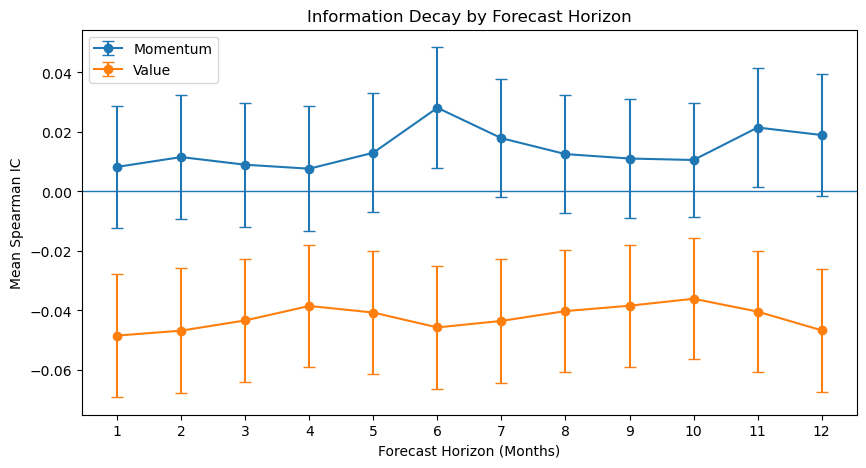

In [49]:
momentum_persistence = momentum_z.corrwith(momentum_z.shift(1), axis=1)
value_persistence = value_z.corrwith(value_z.shift(1), axis=1)

momentum_rho = momentum_persistence.mean()
value_rho = value_persistence.mean()

print("Momentum rho:", momentum_rho)
print("Value rho:", value_rho)

#horizon
horizon = 3

future_residual = residual_returns.shift(-horizon)

ic_3_momentum = momentum_z.corrwith(
    future_residual,
    axis=1,
    method="spearman"
)

ic_3_value = value_z.corrwith(
    future_residual,
    axis=1,
    method="spearman"
)
print("Momentum IC3:", ic_3_momentum.mean())
print("Value IC3:", ic_3_value.mean())

import numpy as np

max_horizon = 12

momentum_ic_decay = []
value_ic_decay = []

momentum_ic_se = []
value_ic_se = []

for horizon in range(1, max_horizon + 1):

    future_residual = residual_returns.shift(-horizon)

    momentum_ic = momentum_z.corrwith(
        future_residual,
        axis=1,
        method="spearman"
    )

    value_ic = value_z.corrwith(
        future_residual,
        axis=1,
        method="spearman"
    )

    momentum_ic_decay.append(momentum_ic.mean())
    value_ic_decay.append(value_ic.mean())

    momentum_ic_se.append(
        momentum_ic.std(ddof=1) / np.sqrt(momentum_ic.count())
    )

    value_ic_se.append(
        value_ic.std(ddof=1) / np.sqrt(value_ic.count())
    )
horizons = range(1, max_horizon + 1)

plt.figure(figsize=(10, 5))

plt.errorbar(
    horizons,
    momentum_ic_decay,
    yerr=momentum_ic_se,
    marker="o",
    capsize=4,
    label="Momentum"
)

plt.errorbar(
    horizons,
    value_ic_decay,
    yerr=value_ic_se,
    marker="o",
    capsize=4,
    label="Value"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Forecast Horizon (Months)")
plt.ylabel("Mean Spearman IC")
plt.title("Information Decay by Forecast Horizon")
plt.xticks(horizons)
plt.legend()

plt.show()